In [1]:
import pandas as pd
import numpy as np

s=pd.Series([1,2,3,None,5,6,pd.NA,8,9])
s.isnull()

0    False
1    False
2    False
3     True
4    False
5    False
6     True
7    False
8    False
dtype: bool

In [2]:
pd.read_csv("data/weather_withna.csv")

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,NaN,NaN,NaN,NaN,NaN
1457,2015-12-28,NaN,NaN,NaN,NaN,NaN
1458,2015-12-29,NaN,NaN,NaN,NaN,NaN
1459,2015-12-30,NaN,NaN,NaN,NaN,NaN


In [3]:
df=pd.read_csv("data/weather_withna.csv",keep_default_na=False)
# 不会自动把空值变成缺失值
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,,,,,
1457,2015-12-28,,,,,
1458,2015-12-29,,,,,
1459,2015-12-30,,,,,
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [5]:
df=pd.read_csv("data/weather_withna.csv", na_values="2015-12-30")
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,NaN,NaN,NaN,NaN
1457,2015-12-28,NaN,NaN,NaN,NaN,NaN
1458,2015-12-29,NaN,NaN,NaN,NaN,NaN
1459,NaN,NaN,NaN,NaN,NaN,NaN
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [6]:
df.isnull().sum()

date               1
precipitation    303
temp_max         303
temp_min         303
wind             303
weather          303
dtype: int64

<Axes: >

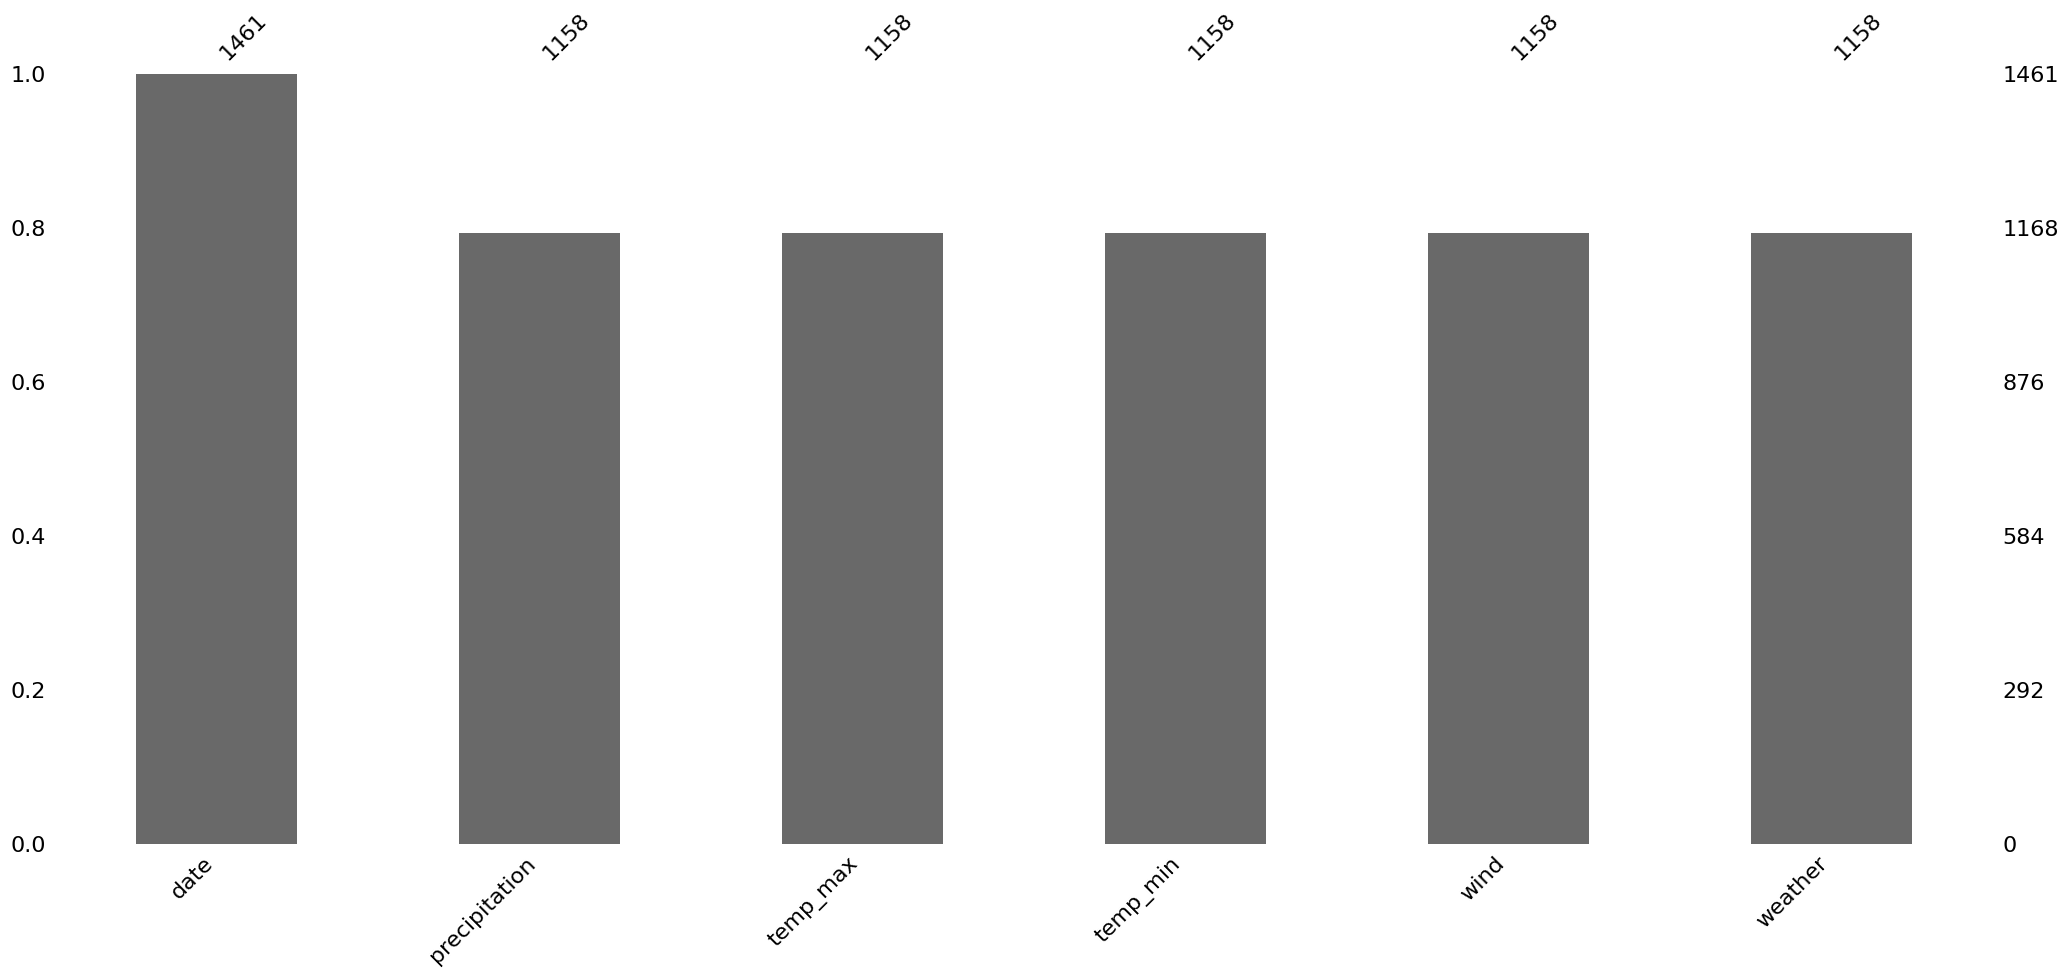

In [7]:
# 将缺失值以柱状图的方式展示，柱子越高说明缺失值数据越多
import missingno as msno
df = pd.read_csv("data/weather_withna.csv")

msno.bar(df)

In [9]:
df.fillna({
    "temp_max": 60,
    "temp_min": -60,
}).tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,60.0,-60.0,NaN,NaN
1457,2015-12-28,NaN,60.0,-60.0,NaN,NaN
1458,2015-12-29,NaN,60.0,-60.0,NaN,NaN
1459,2015-12-30,NaN,60.0,-60.0,NaN,NaN
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [10]:
# 填充缺失，填写为平均值
df.fillna(df[["temp_max","temp_min","wind"]].mean()).tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,15.851468,7.877202,3.242055,NaN
1457,2015-12-28,NaN,15.851468,7.877202,3.242055,NaN
1458,2015-12-29,NaN,15.851468,7.877202,3.242055,NaN
1459,2015-12-30,NaN,15.851468,7.877202,3.242055,NaN
1460,2015-12-31,20.6,12.200000,5.000000,3.800000,rain


In [11]:
df.ffill().tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,0.0,11.1,4.4,4.8,sun
1457,2015-12-28,0.0,11.1,4.4,4.8,sun
1458,2015-12-29,0.0,11.1,4.4,4.8,sun
1459,2015-12-30,0.0,11.1,4.4,4.8,sun
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [12]:
df.bfill().tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,20.6,12.2,5.0,3.8,rain
1457,2015-12-28,20.6,12.2,5.0,3.8,rain
1458,2015-12-29,20.6,12.2,5.0,3.8,rain
1459,2015-12-30,20.6,12.2,5.0,3.8,rain
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [13]:
s = pd.Series([1,2,3,None,5,6,np.nan,8,9])
# 线性插值：取相邻两点的中间值
s.interpolate()

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
6    7.0
7    8.0
8    9.0
dtype: float64